# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/haritharamadass/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can search-performance information available in March 2026 be used to rank content items by their risk of a substantial decline in impressions during April 2026, so that a content team can decide which items to review first?

### Decision supported

A content team cannot manually inspect every content item, so the practical decision is which items should enter the limited review queue first. The model is therefore used as a ranking and decision-support tool rather than as an automatic publishing or content-editing system.

The primary evaluation metric is **Precision@20**, because the most useful outcome is having a high proportion of true future declines among the first 20 items selected for review.

The analysis uses only information available at the March decision point. April performance is used only to define the future outcome. The results are observational and should not be interpreted as causal proof that any individual page will decline.

In [2]:
# ML-11 Capstone — Section 1
# Research question and decision-support frame

research_question = (
    "Can March 2026 search-performance information be used to rank "
    "content items by their risk of a substantial decline in impressions "
    "during April 2026?"
)

decision_supported = (
    "Prioritize which content items a human content team should review first."
)

primary_metric = "Precision@20"
decision_month = "March 2026"
outcome_month = "April 2026"

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

print("\nEvaluation design:")
print("Decision-point features:", decision_month)
print("Future outcome:", outcome_month)
print("Primary metric:", primary_metric)
print("Use: ranking / decision support, not automatic action")

Research question:
Can March 2026 search-performance information be used to rank content items by their risk of a substantial decline in impressions during April 2026?

Decision supported:
Prioritize which content items a human content team should review first.

Evaluation design:
Decision-point features: March 2026
Future outcome: April 2026
Primary metric: Precision@20
Use: ranking / decision support, not automatic action


## 2. Data

### Data source and analysis window

This study uses the **FlyRank ML Internship warehouse dataset**, specifically the `fact_content_daily_performance` table.

The raw March 2026 slice contains **9,841,378 daily records**, covering **55 anonymized clients** and **331,437 content items**. The unit in the raw table is one content item for one client on one report date.

Two monthly windows are used:

- **March 1–31, 2026:** feature and decision window.
- **April 1–30, 2026:** future outcome window only.

March search-performance observations are aggregated to one row per client-content item. After joining eligible content observed in both months and applying the analysis filters, the final modeling frame contains **100,893 content items across 43 clients**.

### Fields used

The model uses four March Google Search Console-derived features:

- `impressions_31d`
- `ctr_31d`
- `avg_position_31d`
- `active_gsc_days`

`client_hash_id` is retained only for grouped validation and `content_hash_id` is retained only as an anonymized content identifier. Neither ID is used as a predictive feature.

### Eligibility and exclusions

Content is excluded when:

- March impressions are below 100.
- March GSC data is unavailable.
- April GSC data needed for the future outcome is unavailable.
- March impression or average-position values needed by the analysis are missing or invalid.
- The content item cannot be matched between the March and April windows.

GA4 metrics are not used in the feature set because their coverage was lower in the March data. April performance is never used as an input feature because doing so would leak future information into the model.

All identifiers used in this analysis are anonymized. No client names, private URLs, or raw search queries are included in the public research artifact.

In [5]:
# ML-11 Capstone — Section 2
# Build the public-safe March -> April analytical feature frame

from google.colab import userdata
import duckdb
import pandas as pd

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError(
        "HF_TOKEN was not found in Colab Secrets. "
        "Add your Hugging Face token before running this notebook."
    )

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

print("Hugging Face access configured successfully.")

# March = information available at the decision point
MARCH = """
read_parquet(
  'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
"""

# April = future window used only for the outcome
APRIL = """
read_parquet(
  'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/*.parquet'
)
"""

feature_frame = con.sql(f"""
WITH march AS (

    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) FILTER (
            WHERE gsc_data_available IS TRUE
        ) AS impressions_31d,

        SUM(gsc_clicks) FILTER (
            WHERE gsc_data_available IS TRUE
        ) AS clicks_31d,

        SUM(
            gsc_avg_position * gsc_impressions
        ) FILTER (
            WHERE gsc_data_available IS TRUE
              AND gsc_impressions > 0
              AND gsc_avg_position > 0
        )
        /
        NULLIF(
            SUM(gsc_impressions) FILTER (
                WHERE gsc_data_available IS TRUE
                  AND gsc_impressions > 0
                  AND gsc_avg_position > 0
            ),
            0
        ) AS avg_position_31d,

        COUNT(*) FILTER (
            WHERE gsc_data_available IS TRUE
        ) AS active_gsc_days

    FROM {MARCH}

    GROUP BY
        client_hash_id,
        content_hash_id
),

april AS (

    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) FILTER (
            WHERE gsc_data_available IS TRUE
        ) AS april_impressions,

        COUNT(*) FILTER (
            WHERE gsc_data_available IS TRUE
        ) AS april_gsc_days

    FROM {APRIL}

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    m.client_hash_id,
    m.content_hash_id,

    m.impressions_31d,
    m.clicks_31d,

    100.0 * m.clicks_31d
        / NULLIF(m.impressions_31d, 0) AS ctr_31d,

    m.avg_position_31d,
    m.active_gsc_days,

    a.april_impressions,

    (
        a.april_impressions
        < 0.80 * m.impressions_31d
    ) AS declined_next_month

FROM march AS m

INNER JOIN april AS a
    ON m.client_hash_id = a.client_hash_id
   AND m.content_hash_id = a.content_hash_id

WHERE
    m.impressions_31d >= 100
    AND m.active_gsc_days > 0
    AND a.april_gsc_days > 0
    AND m.impressions_31d IS NOT NULL
    AND m.avg_position_31d IS NOT NULL
    AND m.avg_position_31d > 0
    AND a.april_impressions IS NOT NULL
""").df()

print("\nFinal analytical frame")
print("-" * 45)
print(f"Rows: {len(feature_frame):,}")
print(f"Clients: {feature_frame['client_hash_id'].nunique()}")
print(f"Content items: {feature_frame['content_hash_id'].nunique():,}")
print("Feature window: March 2026")
print("Outcome window: April 2026")

print("\nModel-input fields:")
print([
    "impressions_31d",
    "ctr_31d",
    "avg_position_31d",
    "active_gsc_days"
])

print("\nPublic-safety check:")
print("Identifiers are hashed/anonymized.")
print("No client names, URLs, or private search queries are used.")

Hugging Face access configured successfully.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Final analytical frame
---------------------------------------------
Rows: 100,893
Clients: 43
Content items: 100,893
Feature window: March 2026
Outcome window: April 2026

Model-input fields:
['impressions_31d', 'ctr_31d', 'avg_position_31d', 'active_gsc_days']

Public-safety check:
Identifiers are hashed/anonymized.
No client names, URLs, or private search queries are used.


## 3. Methodology

### Modeling approach

I use **Logistic Regression** to estimate the probability that an eligible content item will experience a substantial decline in search impressions during the following month. Logistic Regression was selected because the outcome is binary, the model is relatively interpretable, and its probability estimates can be used directly to rank content for human review.

### Outcome definition

The target is `declined_next_month`.

A content item is labeled as a future decline when:

**April impressions < 80% of March impressions**

This corresponds to a decline of more than 20% between the March decision window and the April outcome window.

### Features

Only information available during March 2026 is used as model input:

- `impressions_31d`
- `ctr_31d`
- `avg_position_31d`
- `active_gsc_days`

Client and content identifiers are not predictive features.

### Baseline

The learned model is compared with the transparent rule-based ranking developed earlier in the project. The baseline and Logistic Regression model are evaluated on the **same held-out rows** using the same future label and the same ranking metrics.

The primary metric is **Precision@20**, with Precision@50 used as a secondary check.

### Validation design

The main comparison uses an **80/20 grouped train-test split by client**, with random seed 42. All content belonging to one client stays entirely in either the training or test set.

This prevents the model from being trained on content from the same clients it is later evaluated on.

A stronger validation audit also uses **5-fold GroupKFold by client** to measure how performance varies across multiple groups of unseen clients.

### Leakage checks

Several safeguards are used:

1. April performance is used only to define the future outcome and never as a model feature.
2. `client_hash_id` and `content_hash_id` are excluded from predictive features.
3. Training and test clients have zero overlap.
4. A separate leakage challenge removes `impressions_31d`, the feature most closely related to the label definition, and checks whether the ranking signal remains.

These checks support an honest decision-support interpretation rather than a causal or guaranteed prediction claim.

In [6]:
# ML-11 Capstone — Section 3
# Methodology: grouped split, model, and leakage safeguards

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42

FEATURES = [
    "impressions_31d",
    "ctr_31d",
    "avg_position_31d",
    "active_gsc_days",
]

TARGET = "declined_next_month"
GROUP = "client_hash_id"

# ------------------------------------------------------------
# 1. Honest client-grouped train/test split
# ------------------------------------------------------------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(
        feature_frame,
        groups=feature_frame[GROUP]
    )
)

train_df = feature_frame.iloc[train_idx].copy()
test_df = feature_frame.iloc[test_idx].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET].astype(int)

X_test = test_df[FEATURES]
y_test = test_df[TARGET].astype(int)

# ------------------------------------------------------------
# 2. Leakage checks
# ------------------------------------------------------------

train_clients = set(train_df[GROUP])
test_clients = set(test_df[GROUP])
client_overlap = train_clients.intersection(test_clients)

forbidden_features = {
    "client_hash_id",
    "content_hash_id",
    "april_impressions",
    "declined_next_month"
}

used_forbidden = forbidden_features.intersection(FEATURES)

assert len(client_overlap) == 0, "Client leakage detected."
assert len(used_forbidden) == 0, "Forbidden feature detected."

# ------------------------------------------------------------
# 3. Logistic Regression pipeline
# ------------------------------------------------------------

model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

model.fit(X_train, y_train)

# ------------------------------------------------------------
# 4. Methodology summary
# ------------------------------------------------------------

print("Methodology summary")
print("-" * 50)

print("Model: Logistic Regression")
print("Features:", FEATURES)
print("Target:", TARGET)
print("Grouped by:", GROUP)
print("Random seed:", RANDOM_STATE)

print("\nSplit summary")
print("-" * 50)
print(f"Training rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Training clients: {train_df[GROUP].nunique()}")
print(f"Test clients: {test_df[GROUP].nunique()}")
print(f"Client overlap: {len(client_overlap)}")

print("\nOutcome rates")
print("-" * 50)
print(f"Training decline rate: {y_train.mean():.3f}")
print(f"Test decline rate: {y_test.mean():.3f}")

print("\nLeakage checks")
print("-" * 50)
print("Future April fields used as model features: No")
print("Client/content IDs used as model features: No")
print("Client overlap between train and test:", len(client_overlap))

print("\nModel fitted successfully.")

Methodology summary
--------------------------------------------------
Model: Logistic Regression
Features: ['impressions_31d', 'ctr_31d', 'avg_position_31d', 'active_gsc_days']
Target: declined_next_month
Grouped by: client_hash_id
Random seed: 42

Split summary
--------------------------------------------------
Training rows: 85,702
Test rows: 15,191
Training clients: 34
Test clients: 9
Client overlap: 0

Outcome rates
--------------------------------------------------
Training decline rate: 0.533
Test decline rate: 0.412

Leakage checks
--------------------------------------------------
Future April fields used as model features: No
Client/content IDs used as model features: No
Client overlap between train and test: 0

Model fitted successfully.


## 4. Results (vs baseline)

### Model versus baseline

The Logistic Regression model and the rule-based baseline were evaluated on exactly the same held-out client-grouped test set.

The held-out test set has a future-decline base rate of **0.412**.

At the main ranking cutoff:

- **Rule baseline Precision@20: 0.700**
- **Logistic Regression Precision@20: 0.800**

This means that 14 of the baseline's top 20 items were future declines, compared with **16 of the model's top 20**.

At a wider review cutoff:

- **Rule baseline Precision@50: 0.500**
- **Logistic Regression Precision@50: 0.720**

The learned model therefore produced a better ordering than the hand-built rule on this held-out group of unseen clients.

However, this single split should not be treated as guaranteed future performance. The later 5-fold client-grouped validation produced a mean Precision@20 of **0.710**, showing that ranking performance varies across different unseen client groups. The result should therefore be interpreted as useful directional decision support rather than certainty.

Model vs baseline — same held-out split
-------------------------------------------------------


,Method,Precision@20,Precision@50
0,Held-out base rate,0.412,0.412
1,Rule baseline,0.700,0.500
2,Logistic Regression,0.800,0.720



Top-20 correct future declines:
Rule baseline: 14 of 20
Logistic Regression: 16 of 20


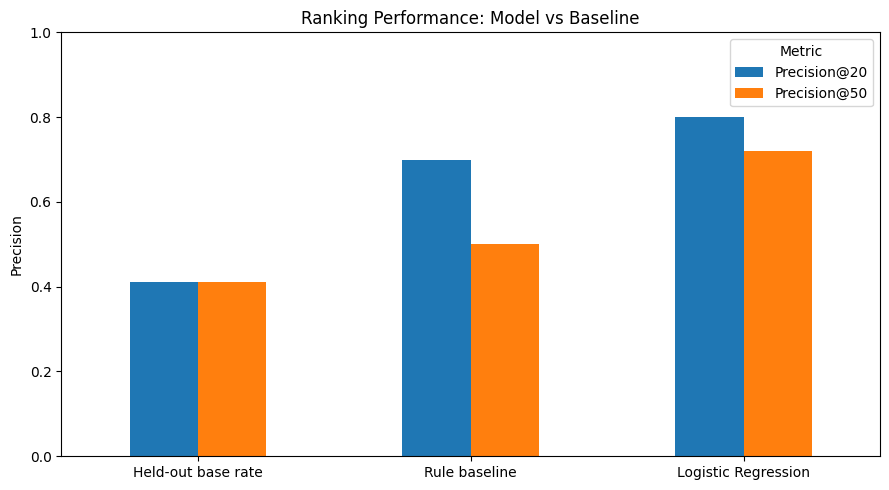

In [7]:
# ML-11 Capstone — Section 4
# Model vs baseline on exactly the same held-out test rows

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Model probabilities for ranking
# ------------------------------------------------------------

test_results = test_df.copy()

test_results["model_probability"] = (
    model.predict_proba(X_test)[:, 1]
)

# ------------------------------------------------------------
# 2. Rebuild the rule baseline
# ------------------------------------------------------------

baseline_test = test_df.copy()

baseline_test["ctr_opportunity"] = (
    (
        (baseline_test["avg_position_31d"] <= 3)
        & (baseline_test["ctr_31d"] < 0.15)
    )
    |
    (
        (baseline_test["avg_position_31d"] > 3)
        & (baseline_test["avg_position_31d"] <= 10)
        & (baseline_test["ctr_31d"] < 0.10)
    )
    |
    (
        (baseline_test["avg_position_31d"] > 10)
        & (baseline_test["avg_position_31d"] <= 20)
        & (baseline_test["ctr_31d"] < 0.05)
    )
)

baseline_test["baseline_score"] = (
    3 * baseline_test["ctr_opportunity"].astype(int)
    + 2 * (
        baseline_test["impressions_31d"] >= 1000
    ).astype(int)
    + 1 * (
        (baseline_test["impressions_31d"] >= 500)
        & (baseline_test["impressions_31d"] < 1000)
    ).astype(int)
    + 1 * (
        baseline_test["avg_position_31d"] <= 20
    ).astype(int)
)

# ------------------------------------------------------------
# 3. Precision@K helper
# ------------------------------------------------------------

def precision_at_k(df, score_column, k):
    ranked = (
        df
        .sort_values(
            by=[score_column, "impressions_31d"],
            ascending=[False, False]
        )
        .head(k)
    )

    return ranked[TARGET].astype(int).mean()

# ------------------------------------------------------------
# 4. Calculate results
# ------------------------------------------------------------

base_rate = y_test.mean()

baseline_p20 = precision_at_k(
    baseline_test,
    "baseline_score",
    20
)

baseline_p50 = precision_at_k(
    baseline_test,
    "baseline_score",
    50
)

model_p20 = precision_at_k(
    test_results,
    "model_probability",
    20
)

model_p50 = precision_at_k(
    test_results,
    "model_probability",
    50
)

comparison = pd.DataFrame({
    "Method": [
        "Held-out base rate",
        "Rule baseline",
        "Logistic Regression"
    ],
    "Precision@20": [
        base_rate,
        baseline_p20,
        model_p20
    ],
    "Precision@50": [
        base_rate,
        baseline_p50,
        model_p50
    ]
})

comparison["Precision@20"] = comparison["Precision@20"].round(3)
comparison["Precision@50"] = comparison["Precision@50"].round(3)

print("Model vs baseline — same held-out split")
print("-" * 55)

display(comparison)

print(f"\nTop-20 correct future declines:")
print(f"Rule baseline: {int(round(baseline_p20 * 20))} of 20")
print(f"Logistic Regression: {int(round(model_p20 * 20))} of 20")

# ------------------------------------------------------------
# 5. Results chart
# ------------------------------------------------------------

chart_data = comparison.set_index("Method")[
    ["Precision@20", "Precision@50"]
]

ax = chart_data.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Ranking Performance: Model vs Baseline")
ax.set_ylabel("Precision")
ax.set_xlabel("")
ax.set_ylim(0, 1.0)
ax.legend(title="Metric")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Limitations

### Limitations and honest framing

This analysis provides evidence of useful ranking signal, but it has several important limitations.

**1. The results are observational, not causal.**  
The model identifies patterns associated with next-month impression decline. It does not prove that any feature causes a decline, and it does not prove that a recommended content change will improve performance.

**2. Performance varies across unseen clients.**  
The single grouped holdout produced Precision@20 of **0.800**, but stronger 5-fold client-grouped validation produced a mean Precision@20 of **0.710**, with fold results ranging from approximately **0.50 to 0.90**. The single holdout should therefore not be treated as a guaranteed performance level.

**3. The model still makes mistakes.**  
On the main held-out test set, 16 of the model's top 20 ranked items were future declines. The remaining 4 were false positives. Human review is therefore required before taking action.

**4. The study covers one March-to-April 2026 transition.**  
Search behavior may vary by season, topic, market conditions, algorithm changes, and client mix. Performance across other months may differ.

**5. The analysis uses an eligibility-filtered subset.**  
Content with fewer than 100 March impressions or insufficient GSC observations is excluded. The conclusions therefore apply to the eligible content population rather than every page in the warehouse.

**6. The feature set is intentionally limited.**  
The model uses four GSC-derived features. GA4 metrics and richer content characteristics are not included, so potentially useful information may be missing.

**7. A risk score is decision support, not certainty.**  
The ranking should help a content strategist decide what to inspect first. It should not automatically trigger edits, deletion, publishing, or other content actions.

In [8]:
# ML-11 Capstone — Section 5
# Quantify uncertainty and validation variability

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# 1. Five-fold validation grouped by client
# ------------------------------------------------------------

model_data = feature_frame.copy()

X_all = model_data[FEATURES]
y_all = model_data[TARGET].astype(int)
groups_all = model_data[GROUP]

gkf = GroupKFold(n_splits=5)

fold_results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X_all, y_all, groups_all),
    start=1
):
    X_fold_train = X_all.iloc[train_idx]
    y_fold_train = y_all.iloc[train_idx]

    X_fold_test = X_all.iloc[test_idx]

    fold_model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "logistic_regression",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ])

    fold_model.fit(X_fold_train, y_fold_train)

    probabilities = fold_model.predict_proba(
        X_fold_test
    )[:, 1]

    fold_test = model_data.iloc[test_idx].copy()
    fold_test["model_probability"] = probabilities

    ranked_top20 = (
        fold_test
        .sort_values(
            by=["model_probability", "impressions_31d"],
            ascending=[False, False]
        )
        .head(20)
    )

    p20 = (
        ranked_top20[TARGET]
        .astype(int)
        .mean()
    )

    train_clients = set(
        model_data.iloc[train_idx][GROUP]
    )

    test_clients = set(
        model_data.iloc[test_idx][GROUP]
    )

    overlap = len(
        train_clients.intersection(test_clients)
    )

    fold_results.append({
        "Fold": fold,
        "Test rows": len(test_idx),
        "Test clients": len(test_clients),
        "Client overlap": overlap,
        "Precision@20": p20
    })

cv_results = pd.DataFrame(fold_results)

print("5-fold client-grouped validation")
print("-" * 55)

display(
    cv_results.round({
        "Precision@20": 3
    })
)

mean_p20 = cv_results["Precision@20"].mean()
min_p20 = cv_results["Precision@20"].min()
max_p20 = cv_results["Precision@20"].max()

# ------------------------------------------------------------
# 2. Errors on the main held-out top 20
# ------------------------------------------------------------

heldout_top20 = (
    test_results
    .sort_values(
        by=["model_probability", "impressions_31d"],
        ascending=[False, False]
    )
    .head(20)
)

correct_top20 = (
    heldout_top20[TARGET]
    .astype(int)
    .sum()
)

false_positives = 20 - correct_top20

print("\nLimitation summary")
print("-" * 55)
print(f"Single grouped holdout Precision@20: {model_p20:.3f}")
print(f"5-fold mean Precision@20: {mean_p20:.3f}")
print(f"5-fold minimum Precision@20: {min_p20:.3f}")
print(f"5-fold maximum Precision@20: {max_p20:.3f}")
print(f"False positives in held-out top 20: {false_positives}")
print("Client overlap in every fold:",
      int(cv_results["Client overlap"].max()))

print("\nInterpretation:")
print(
    "Performance varies across unseen client groups, "
    "so the ranking is directional decision support, "
    "not a guaranteed prediction."
)

5-fold client-grouped validation
-------------------------------------------------------


,Fold,Test rows,Test clients,Client overlap,Precision@20
0,1,21620,1,0,0.70
1,2,19800,10,0,0.90
2,3,19800,13,0,0.50
3,4,19874,7,0,0.55
4,5,19799,12,0,0.90



Limitation summary
-------------------------------------------------------
Single grouped holdout Precision@20: 0.800
5-fold mean Precision@20: 0.710
5-fold minimum Precision@20: 0.500
5-fold maximum Precision@20: 0.900
False positives in held-out top 20: 4
Client overlap in every fold: 0

Interpretation:
Performance varies across unseen client groups, so the ranking is directional decision support, not a guaranteed prediction.


## 6. Ranked recommendations

### Ranked action recommendations

The model score is used to decide **what a content strategist should review first**, not to make automatic content changes.

Based on the validated ranking and the ML-10 action playbook, I recommend the following order of action:

**1. Review the highest-risk content first.**  
Start with the model's top-ranked items because review capacity is limited. The ranking concentrates human attention on content with the strongest measured next-month decline signal.

**2. Investigate low CTR relative to search position.**  
When a page ranks reasonably well but receives unusually low CTR, review the title, search snippet, search intent alignment, and relevance before making changes.

**3. Investigate high-visibility content at risk.**  
For pages with substantial impression volume, check freshness, relevance, competition, and recent search-performance changes. These pages may deserve earlier attention because more search visibility is potentially at stake.

**4. Use a general diagnostic review for remaining high-risk items.**  
If no specific explanation is supported by the available features, keep the item on a manual watchlist and investigate it rather than assuming a particular fix.

Freshness is treated as a review hypothesis rather than a guaranteed solution. The analysis does not establish that refreshing a page causes improved search performance.

Every recommendation requires **human review before editing, pruning, publishing, or otherwise changing content**.

In [9]:
# ML-11 Capstone — Section 6
# Turn model ranking into a human-review action queue

import pandas as pd

# ------------------------------------------------------------
# 1. Take the top 20 items from the validated model ranking
# ------------------------------------------------------------

action_queue = (
    test_results
    .sort_values(
        by=["model_probability", "impressions_31d"],
        ascending=[False, False]
    )
    .head(20)
    .copy()
    .reset_index(drop=True)
)

action_queue["rank"] = range(1, len(action_queue) + 1)
action_queue["risk_score"] = (
    action_queue["model_probability"].round(4)
)

# ------------------------------------------------------------
# 2. Assign a transparent review archetype
# ------------------------------------------------------------

def assign_action(row):

    # High visibility + clearly weak CTR
    if (
        row["impressions_31d"] >= 1000
        and row["ctr_31d"] < 0.10
    ):
        return pd.Series({
            "archetype": "HIGH_VISIBILITY_LOW_CTR",
            "reason_code": "LOW_CTR_HIGH_VISIBILITY",
            "recommended_action":
                "REVIEW_SNIPPET_INTENT_AND_FRESHNESS"
        })

    # CTR looks weak relative to current search position
    low_ctr_for_position = (
        (
            row["avg_position_31d"] <= 3
            and row["ctr_31d"] < 0.15
        )
        or
        (
            3 < row["avg_position_31d"] <= 10
            and row["ctr_31d"] < 0.10
        )
        or
        (
            10 < row["avg_position_31d"] <= 20
            and row["ctr_31d"] < 0.05
        )
    )

    if low_ctr_for_position:
        return pd.Series({
            "archetype": "LOW_CTR_FOR_POSITION",
            "reason_code": "LOW_CTR_FOR_POSITION",
            "recommended_action":
                "REVIEW_TITLE_SNIPPET_AND_INTENT"
        })

    # High visibility without a specific CTR diagnosis
    if row["impressions_31d"] >= 1000:
        return pd.Series({
            "archetype": "HIGH_VISIBILITY_RISK",
            "reason_code": "HIGH_VOLUME_OPPORTUNITY",
            "recommended_action":
                "CHECK_FRESHNESS_RELEVANCE_AND_COMPETITION"
        })

    # Otherwise keep as a general human-review candidate
    return pd.Series({
        "archetype": "GENERAL_RISK_WATCHLIST",
        "reason_code": "MODEL_RISK_WATCHLIST",
        "recommended_action":
            "MANUAL_DIAGNOSTIC_REVIEW"
    })


actions = action_queue.apply(assign_action, axis=1)

action_queue = pd.concat(
    [action_queue, actions],
    axis=1
)

action_queue["human_review_required"] = True

# ------------------------------------------------------------
# 3. Public-safe review queue
# ------------------------------------------------------------

queue_display = action_queue[[
    "rank",
    "content_hash_id",
    "risk_score",
    "impressions_31d",
    "ctr_31d",
    "avg_position_31d",
    "archetype",
    "reason_code",
    "recommended_action",
    "human_review_required"
]]

print("Top-20 ranked action queue")
print("-" * 60)

display(queue_display)

print("\nAction archetype counts")
print("-" * 60)

display(
    action_queue["archetype"]
    .value_counts()
    .rename_axis("Archetype")
    .reset_index(name="Items")
)

print("\nSafety rule:")
print(
    "The queue prioritizes human review only; "
    "it does not automatically change or publish content."
)

Top-20 ranked action queue
------------------------------------------------------------


,rank,content_hash_id,risk_score,impressions_31d,ctr_31d,avg_position_31d,archetype,reason_code,recommended_action,human_review_required
0,1,content_e3a63930f7422987,0.6729,447.0,0.0,2.025641,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT,True
1,2,content_e4b8aa114663611b,0.6728,206.0,0.0,2.887805,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT,True
2,3,content_db9d5ae0c17b7460,0.6724,551.0,0.0,1.979048,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT,True
3,4,content_4a25999c6672a162,0.6711,430.0,0.0,3.222749,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT,True
4,5,content_9eeba1f980fd7436,0.6711,587.0,0.0,2.749574,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT,True
5,6,content_93070561f9b163c3,0.6710,645.0,0.0,2.587597,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT,True
6,7,content_26ad8c3d6d0e6755,0.6709,320.0,0.0,3.718447,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT,True
7,8,content_56467aab5997e039,0.6707,231.0,0.0,4.169082,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT,True
8,9,content_5e9ca17e3735e391,0.6706,462.0,0.0,3.461039,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT,True
9,10,content_e47b91d6e5daef37,0.6705,143.0,0.0,4.608392,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT,True



Action archetype counts
------------------------------------------------------------


,Archetype,Items
0,LOW_CTR_FOR_POSITION,20



Safety rule:
The queue prioritizes human review only; it does not automatically change or publish content.


## 7. Artifacts the paper embeds

### Paper artifacts

The deployed research paper will use a small set of public-safe artifacts that communicate the main result without exposing private data.

**Artifact 1 — Model vs baseline comparison**  
A table and chart comparing the held-out base rate, rule baseline, and Logistic Regression using Precision@20 and Precision@50.

**Artifact 2 — Cross-client validation summary**  
A table showing Precision@20 across the five client-grouped validation folds. This makes the variation in model performance visible instead of reporting only the best single split.

**Artifact 3 — Top-20 action queue summary**  
A public-safe ranked table containing anonymized content IDs, model risk scores, search-performance indicators, reason codes, and recommended human-review actions.

Together, these artifacts support the paper's main story: the learned model improves the held-out ranking over the rule baseline, but performance varies across unseen client groups and every recommended action still requires human judgment.

ARTIFACT 1 — Model vs baseline
------------------------------------------------------------


,Method,Precision@20,Precision@50
0,Held-out base rate,0.412,0.412
1,Rule baseline,0.700,0.500
2,Logistic Regression,0.800,0.720



ARTIFACT 2 — 5-fold client-grouped validation
------------------------------------------------------------


,Fold,Test rows,Test clients,Client overlap,Precision@20
0,1,21620,1,0,0.70
1,2,19800,10,0,0.90
2,3,19800,13,0,0.50
3,4,19874,7,0,0.55
4,5,19799,12,0,0.90


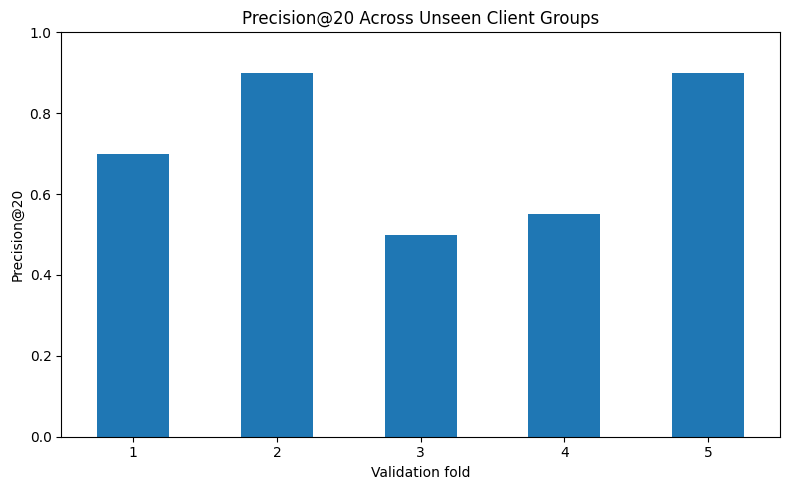


ARTIFACT 3 — Top-20 action queue
------------------------------------------------------------


,rank,content_hash_id,risk_score,impressions_31d,ctr_31d,avg_position_31d,archetype,reason_code,recommended_action
0,1,content_e3a63930f7422987,0.6729,447.0,0.0,2.025641,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT
1,2,content_e4b8aa114663611b,0.6728,206.0,0.0,2.887805,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT
2,3,content_db9d5ae0c17b7460,0.6724,551.0,0.0,1.979048,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT
3,4,content_4a25999c6672a162,0.6711,430.0,0.0,3.222749,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT
4,5,content_9eeba1f980fd7436,0.6711,587.0,0.0,2.749574,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT
5,6,content_93070561f9b163c3,0.6710,645.0,0.0,2.587597,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT
6,7,content_26ad8c3d6d0e6755,0.6709,320.0,0.0,3.718447,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT
7,8,content_56467aab5997e039,0.6707,231.0,0.0,4.169082,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT
8,9,content_5e9ca17e3735e391,0.6706,462.0,0.0,3.461039,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT
9,10,content_e47b91d6e5daef37,0.6705,143.0,0.0,4.608392,LOW_CTR_FOR_POSITION,LOW_CTR_FOR_POSITION,REVIEW_TITLE_SNIPPET_AND_INTENT



Paper artifact registry
------------------------------------------------------------


,Artifact,Paper section,Public safe
0,Model vs baseline comparison,Results,True
1,5-fold validation summary,Limitations,True
2,Top-20 action queue,Ranked recommendations,True



Artifact check complete.
No client names, private URLs, or raw search queries are included.


In [10]:
# ML-11 Capstone — Section 7
# Collect the public-safe artifacts used by the deployed paper

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Artifact 1 — Model vs baseline table
# ------------------------------------------------------------

paper_results_table = comparison.copy()

print("ARTIFACT 1 — Model vs baseline")
print("-" * 60)
display(paper_results_table)

# ------------------------------------------------------------
# Artifact 2 — Cross-client validation table
# ------------------------------------------------------------

paper_validation_table = cv_results[[
    "Fold",
    "Test rows",
    "Test clients",
    "Client overlap",
    "Precision@20"
]].copy()

paper_validation_table["Precision@20"] = (
    paper_validation_table["Precision@20"].round(3)
)

print("\nARTIFACT 2 — 5-fold client-grouped validation")
print("-" * 60)
display(paper_validation_table)

# Validation chart
ax = paper_validation_table.plot(
    x="Fold",
    y="Precision@20",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

ax.set_title("Precision@20 Across Unseen Client Groups")
ax.set_xlabel("Validation fold")
ax.set_ylabel("Precision@20")
ax.set_ylim(0, 1.0)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Artifact 3 — Public-safe top-20 action queue
# ------------------------------------------------------------

paper_action_queue = action_queue[[
    "rank",
    "content_hash_id",
    "risk_score",
    "impressions_31d",
    "ctr_31d",
    "avg_position_31d",
    "archetype",
    "reason_code",
    "recommended_action"
]].copy()

print("\nARTIFACT 3 — Top-20 action queue")
print("-" * 60)
display(paper_action_queue)

# ------------------------------------------------------------
# Artifact registry
# ------------------------------------------------------------

artifact_registry = pd.DataFrame({
    "Artifact": [
        "Model vs baseline comparison",
        "5-fold validation summary",
        "Top-20 action queue"
    ],
    "Paper section": [
        "Results",
        "Limitations",
        "Ranked recommendations"
    ],
    "Public safe": [
        True,
        True,
        True
    ]
})

print("\nPaper artifact registry")
print("-" * 60)
display(artifact_registry)

print("\nArtifact check complete.")
print("No client names, private URLs, or raw search queries are included.")